In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

Mounted at /content/drive


In [ ]:
# ====================== PATHS + (OPTIONAL) SPEEDUP FOR COLAB DRIVE ======================
import os, sys, subprocess

base_dir = '/content/drive/MyDrive/HAM10000'
split_dir = os.path.join(base_dir, 'splits')
raw_dir = os.path.join(base_dir, 'raw')

# Nếu train trên Colab + Google Drive: I/O rất chậm. Copy ảnh sang local disk (/content) để tăng tốc đáng kể.
USE_LOCAL_DISK_IF_AVAILABLE = True
local_base_dir = '/content/HAM10000'
local_raw_dir = os.path.join(local_base_dir, 'raw')

def _maybe_copy_to_local():
    if not USE_LOCAL_DISK_IF_AVAILABLE:
        return False
    if not os.path.exists('/content'):
        return False  # không phải Colab/runtime kiểu /content
    if not os.path.exists(raw_dir):
        return False
    # nếu đã có local_raw_dir thì thôi
    if os.path.exists(local_raw_dir) and len(os.listdir(local_raw_dir)) > 0:
        return True
    os.makedirs(local_raw_dir, exist_ok=True)
    print('⏳ Copy raw images from Drive -> local /content (one-time)...')
    # rsync nhanh hơn shutil khi nhiều file
    try:
        subprocess.check_call(['rsync', '-a', raw_dir + '/', local_raw_dir + '/'])
        print('✅ Copy done')
        return True
    except Exception as e:
        print('⚠️ rsync failed, fallback to using Drive directly. Reason:', e)
        return False

use_local = _maybe_copy_to_local()
if use_local:
    raw_dir = local_raw_dir
    print('✅ Using local raw_dir:', raw_dir)
else:
    print('ℹ️ Using Drive raw_dir:', raw_dir)

part1_dir = os.path.join(raw_dir, 'HAM10000_images_part_1')
part2_dir = os.path.join(raw_dir, 'HAM10000_images_part_2')

In [ ]:
# ====================== LOAD CSV ======================
train_df = pd.read_csv(os.path.join(split_dir, 'train_split.csv'))
val_df   = pd.read_csv(os.path.join(split_dir, 'val_split.csv'))
test_df  = pd.read_csv(os.path.join(split_dir, 'test_split.csv'))

class_names = np.load(os.path.join(base_dir, 'class_names.npy'), allow_pickle=True).tolist()

print(f"✅ Load splits thành công!")
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Classes: {class_names}")
print(f"\nCác cột trong train_df: {train_df.columns.tolist()}")

# ====================== XÁC ĐỊNH CỘT QUAN TRỌNG ======================
image_col = 'image_id'
label_col = 'dx'
print(f"→ Sử dụng cột ảnh: '{image_col}' | cột nhãn: '{label_col}'")

# ====================== THÊM ĐUÔI .jpg + TẠO ĐƯỜNG DẪN ĐẦY ĐỦ ======================
for df in [train_df, val_df, test_df]:
    # Thêm đuôi .jpg nếu chưa có
    df[image_col] = df[image_col].astype(str).apply(lambda x: x if x.lower().endswith('.jpg') else x + '.jpg')

    # Ưu tiên dùng cột image_path nếu có và hợp lệ, ngược lại tự tìm trong 2 part
    if 'image_path' in df.columns:
        df['full_path'] = df['image_path'].where(df['image_path'].notna() & df['image_path'].astype(str).str.contains('HAM10000_images'), None)

    # Nếu chưa có full_path hợp lệ thì tìm trong part_1 và part_2
    def find_image_path(img_name):
        for part_dir in [part1_dir, part2_dir]:
            path = os.path.join(part_dir, img_name)
            if os.path.exists(path):
                return path
        return None

    mask = df.get('full_path', pd.Series([None]*len(df))).isnull()
    df.loc[mask, 'full_path'] = df.loc[mask, image_col].apply(find_image_path)

# Kiểm tra ảnh bị thiếu
missing_train = train_df['full_path'].isnull().sum()
if missing_train > 0:
    print(f"⚠️ Cảnh báo: {missing_train} ảnh trong train không tìm thấy!")

✅ Load splits thành công!
Train: 7010 | Val: 1502 | Test: 1503
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

Các cột trong train_df: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'label', 'image_path']
→ Sử dụng cột ảnh: 'image_id' | cột nhãn: 'dx'


✅ Train: 7010 | Val: 1502 | Test: 1503
Classes (7): ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


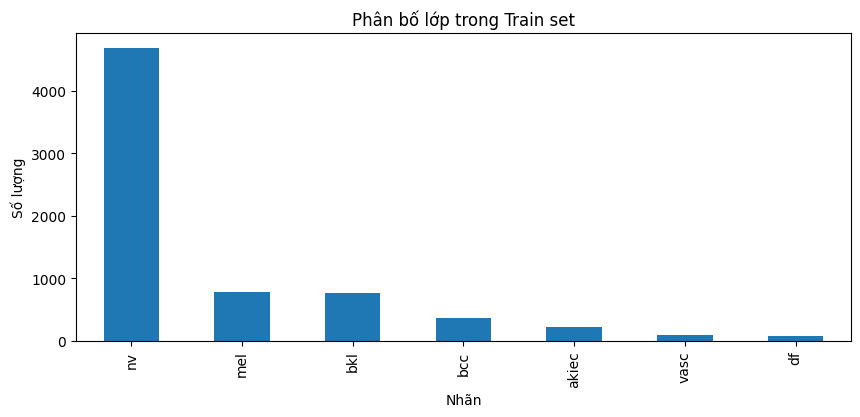

In [ ]:
print(f"✅ Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Classes ({len(class_names)}): {class_names}")

# Kiểm tra class distribution
plt.figure(figsize=(10,4))
train_df['dx'].value_counts().plot(kind='bar')
plt.title('Phân bố lớp trong Train set')
plt.xlabel('Nhãn')
plt.ylabel('Số lượng')
plt.show()

In [ ]:
# ====================== DATA AUGMENTATION + CLASS WEIGHTING ======================
# Giữ nguyên logic xử lý dữ liệu/augment; chỉ chỉnh input size + batch + class_mode để khớp training CNN mới (Keras).
class_counts = train_df[label_col].value_counts().sort_index()
rare_threshold = max(120, int(class_counts.quantile(0.40)))
rare_classes = class_counts[class_counts <= rare_threshold].index.tolist()

print(f"Ngưỡng lớp hiếm: <= {rare_threshold} mẫu")
print(f"Các lớp hiếm được bật selective augmentation: {rare_classes}")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.08,
    horizontal_flip=True,
    fill_mode='nearest'
 )

val_test_datagen = ImageDataGenerator(rescale=1./255)

# ====== CONFIG CHO CNN MỚI ======
batch_size = 128
img_size = (28, 28)  # theo kiến trúc đề xuất

# ====================== TẠO GENERATORS ======================
# Dùng sparse labels để phù hợp SparseCategoricalCrossentropy.
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='full_path',
    y_col=label_col,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=True,
    seed=42,
 )

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='full_path',
    y_col=label_col,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=False,
 )

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='full_path',
    y_col=label_col,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=False,
 )

# ====================== LIGHTWEIGHT CLASS WEIGHT ======================
# Không ép cân bằng tuyệt đối; dùng nghịch đảo tần suất đã làm mượt bằng căn bậc hai + clipping.
freq = class_counts.astype(float)
inv_freq = freq.max() / freq
smoothed_weights = np.sqrt(inv_freq)
smoothed_weights = smoothed_weights / smoothed_weights.mean()
smoothed_weights = smoothed_weights.clip(lower=0.75, upper=3.20)

# Y tế da liễu: tăng nhẹ MEL để giảm false negative.
if 'mel' in smoothed_weights.index:
    smoothed_weights.loc['mel'] = min(3.20, smoothed_weights.loc['mel'] * 1.15)

smoothed_weights = smoothed_weights / smoothed_weights.mean()
class_weight_by_label = smoothed_weights.to_dict()

# Map weight theo thứ tự index mà generator đang dùng (tránh lệch index)
class_weight_dict = {
    int(idx): float(class_weight_by_label.get(cls_name, 1.0))
    for cls_name, idx in train_generator.class_indices.items()
}

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


In [ ]:
print("\n📊 Class weights (lightweight, smoothed):")
# In theo thứ tự index của generator để dễ đối chiếu
idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
for i in range(len(idx_to_class)):
    cls_name = idx_to_class[i]
    count = int((train_df[label_col] == cls_name).sum())
    rare_tag = "(RARE)" if cls_name in rare_classes else ""
    w = float(class_weight_dict.get(i, 1.0))
    print(f"  Lớp {i:2d} ({cls_name:>15}) | count={count:4d} | weight={w:.4f} {rare_tag}")

print("\n" + "="*80)
print("✅ DATA PIPELINE SẴN SÀNG!")
print("   • Train: ImageDataGenerator augment nhẹ + rescale")
print("   • Val/Test: chỉ rescale")
print("   • Labels: sparse (int) để dùng SparseCategoricalCrossentropy")
print("   • img_size =", img_size, "| batch_size =", batch_size)
print("\nBạn có thể chạy cell tiếp theo để build & train CNN mới.")

print("\nPhân bố lớp trong Train:")
print(train_df[label_col].value_counts().sort_index())
print(f"\nCác lớp hiếm (để tham khảo): {rare_classes}")


📊 Class weights (balancing):
  Lớp  0 (          akiec): 4.3731
  Lớp  1 (            bcc): 2.7817
  Lớp  2 (            bkl): 1.3022
  Lớp  3 (             df): 12.3633
  Lớp  4 (            mel): 1.2855
  Lớp  5 (             nv): 0.2134
  Lớp  6 (           vasc): 10.1154

✅ CELL 1 HOÀN TẤT!
   • Train: Augmentation on-the-fly + Class Weight balancing
   • Val & Test: Chỉ rescale
   • Sử dụng cột image_id làm tên ảnh, full_path tự tìm trong part_1 & part_2

Bạn có thể chạy cell tiếp theo xây dựng mô hình.

Phân bố lớp trong Train:
dx
akiec     229
bcc       360
bkl       769
df         81
mel       779
nv       4693
vasc       99
Name: count, dtype: int64


In [ ]:
# ====================== KERAS SETUP (NO PHASE A/B) ======================
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras

# reproducibility
SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

NUM_CLASSES = 7
EPOCHS = 50

# checkpoint dir (giữ theo base_dir đã khai báo ở trên)
CKPT_DIR = os.path.join(base_dir, "checkpoints_custom_cnn")
os.makedirs(CKPT_DIR, exist_ok=True)
CKPT_PATH = os.path.join(CKPT_DIR, "custom_cnn_best.keras")

print("✅ TensorFlow:", tf.__version__)
print("✅ img_size:", img_size, "| batch_size:", batch_size)
print("✅ checkpoint:", CKPT_PATH)

✅ Device: cuda


In [ ]:
# ====================== CUSTOM CNN ARCHITECTURE (HAM10000 - 7 classes) ======================
from tensorflow.keras import layers

def build_custom_cnn(input_shape=(28, 28, 3), num_classes=7):
    """
    Kiến trúc theo mô tả bạn đưa, với chỉnh sửa nhỏ để KHỚP kích thước feature map:
    - Conv dùng padding='same' để giữ kích thước HxW sau conv
    - MaxPool dùng padding='same' để đi từ 7->4 và 4->2 (Keras mặc định floor nếu padding='valid')
    Kết quả: (28,28) -> (14,14) -> (7,7) -> (4,4) -> (2,2), Flatten = 2*2*128 = 512.
    """
    model = keras.Sequential(
        [
            layers.Input(shape=input_shape),
            # Block 1
            layers.Conv2D(16, (3, 3), strides=1, padding="same", activation="relu"),
            layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding="same"),
            # Block 2
            layers.Conv2D(32, (3, 3), strides=1, padding="same", activation="relu"),
            layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding="same"),
            # Block 3
            layers.Conv2D(64, (3, 3), strides=1, padding="same", activation="relu"),
            layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding="same"),
            # Block 4
            layers.Conv2D(128, (3, 3), strides=1, padding="same", activation="relu"),
            layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding="same"),
            # Flatten + Head
            layers.Flatten(),
            layers.Dense(64, activation="relu"),
            layers.Dense(32, activation="relu"),
            layers.Dense(num_classes, activation="softmax"),
        ],
        name="CustomCNN_HAM10000",
    )
    return model

model = build_custom_cnn(input_shape=(img_size[0], img_size[1], 3), num_classes=NUM_CLASSES)
model.summary()

✅ Train batches: 220 | Val: 47 | Test: 47


In [ ]:
# ====================== COMPILE + CALLBACKS ======================
import sys, subprocess
from sklearn.metrics import f1_score

# tqdm (for PyTorch-like progress bars)
try:
    from tqdm.auto import tqdm
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tqdm"])
    from tqdm.auto import tqdm

class TqdmTrainEpochProgress(keras.callbacks.Callback):
    """Hiển thị progress bar theo epoch kiểu: Train Epoch k: 100%|...| steps/steps [.., it/s]."""
    def __init__(self, show_postfix=True):
        super().__init__()
        self.show_postfix = show_postfix
        self.pbar = None

    def on_epoch_begin(self, epoch, logs=None):
        total_steps = self.params.get("steps")
        self.pbar = tqdm(total=total_steps, desc=f"Train Epoch {epoch+1}", leave=True)

    def on_train_batch_end(self, batch, logs=None):
        if self.pbar is None:
            return
        self.pbar.update(1)
        if self.show_postfix and logs:
            postfix = {}
            if "loss" in logs:
                postfix["loss"] = f"{logs['loss']:.4f}"
            if "accuracy" in logs:
                postfix["acc"] = f"{logs['accuracy']:.4f}"
            if postfix:
                self.pbar.set_postfix(postfix, refresh=False)

    def on_epoch_end(self, epoch, logs=None):
        if self.pbar is not None:
            self.pbar.close()
            self.pbar = None

class MacroF1Callback(keras.callbacks.Callback):
    """Tính macro-F1 trên validation (có thể bật theo chu kỳ để tránh chậm)."""
    def __init__(self, val_gen, every_n_epochs=5):
        super().__init__()
        self.val_gen = val_gen
        self.every_n_epochs = int(max(1, every_n_epochs))

    def on_epoch_end(self, epoch, logs=None):
        # chạy mỗi N epoch để giảm overhead I/O/predict
        if (epoch + 1) % self.every_n_epochs != 0:
            return
        logs = logs or {}
        self.val_gen.reset()
        probs = self.model.predict(self.val_gen, verbose=0)
        y_pred = np.argmax(probs, axis=1)
        y_true = self.val_gen.classes.astype(int)
        f1 = f1_score(y_true, y_pred, average="macro")
        logs["val_f1_macro"] = f1
        print(f"val_f1_macro: {f1:.4f} (epoch {epoch+1})")

model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

callbacks = [
    TqdmTrainEpochProgress(show_postfix=True),
    # Đổi every_n_epochs=1 nếu bạn muốn có F1 mỗi epoch (nhưng sẽ chậm hơn).
    MacroF1Callback(val_generator, every_n_epochs=5),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=CKPT_PATH,
        monitor="val_accuracy",
        save_best_only=True,
    ),
]

print("✅ Ready to train (tqdm per-epoch; val_f1_macro every 5 epochs)")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 87.2MB/s]


Output shape: torch.Size([2, 8])
Total parameters: 4882153


In [ ]:
# ====================== TRAIN ======================
# verbose=0 để tránh progress bar mặc định của Keras (đã dùng tqdm callback).
# workers/max_queue_size giúp prefetch batch trong background (giảm nghẽn I/O).
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=0,
    workers=4,
    use_multiprocessing=True,
    max_queue_size=32,
 )

In [ ]:
# ====================== PLOT TRAINING CURVES ======================
import matplotlib.pyplot as plt

hist = history.history
epochs_range = range(1, len(hist.get("loss", [])) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, hist.get("loss", []), label="train_loss")
plt.plot(epochs_range, hist.get("val_loss", []), label="val_loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, hist.get("accuracy", []), label="train_acc")
plt.plot(epochs_range, hist.get("val_accuracy", []), label="val_acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ====================== EVALUATE ON TEST (REPORT + CONFUSION MATRIX) ======================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Evaluate scalar metrics
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\nTEST | loss={test_loss:.4f} | acc={test_acc:.4f}")

# Predict probabilities
probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(probs, axis=1)

# True labels from generator
y_true = test_generator.classes.astype(int)

# Class name order follows generator indices
idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
ordered_class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=ordered_class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=ordered_class_names, yticklabels=ordered_class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Per-class metric table (for optional plotting)
report = classification_report(y_true, y_pred, target_names=ordered_class_names, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report.head()

In [ ]:
# ====================== LOAD BEST CHECKPOINT + RE-EVALUATE ======================
from tensorflow import keras

if os.path.exists(CKPT_PATH):
    best_model = keras.models.load_model(CKPT_PATH)
    best_loss, best_acc = best_model.evaluate(test_generator, verbose=1)
    print(f"\nBEST CKPT TEST | loss={best_loss:.4f} | acc={best_acc:.4f}")
else:
    print("⚠️ Không thấy checkpoint ở:", CKPT_PATH)

Train Epoch 1:   0%|          | 0/220 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Valid:   0%|          | 0/47 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freez

[Phase A][Epoch 1/15] Train Loss: 1.2538 | Train Acc: 0.664 | Val Loss: 1.1432 | Val Acc: 0.686 | F1: 0.254
🔥 New best model found (Val Acc: 0.686)


Valid:   0%|          | 0/47 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[Phase A][Epoch 2/15] Train Loss: 1.0859 | Train Acc: 0.714 | Val Loss: 1.0425 | Val Acc: 0.720 | F1: 0.396
🔥 New best model found (Val Acc: 0.720)


Valid:   0%|          | 0/47 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


...

[Phase A][Epoch 13/15] Train Loss: 0.7773 | Train Acc: 0.864 | Val Loss: 0.8026 | Val Acc: 0.840 | F1: 0.685


Valid:   0%|          | 0/47 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[Phase A][Epoch 14/15] Train Loss: 0.7649 | Train Acc: 0.865 | Val Loss: 0.7862 | Val Acc: 0.861 | F1: 0.713
🔥 New best model found (Val Acc: 0.861)


Valid:   0%|          | 0/47 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[Phase A][Epoch 15/15] Train Loss: 0.7677 | Train Acc: 0.869 | Val Loss: 0.7864 | Val Acc: 0.858 | F1: 0.707


In [ ]:
# ====================== (OPTIONAL) PER-CLASS METRIC BARS ======================
import numpy as np
import matplotlib.pyplot as plt

if 'df_report' not in locals():
    print("⚠️ Chưa có df_report. Hãy chạy cell Evaluate trước.")
else:
    class_rows = df_report.index.difference(["accuracy", "macro avg", "weighted avg"])
    df_cls = df_report.loc[class_rows].copy()

    metrics = ["precision", "recall", "f1-score"]
    class_names_plot = df_cls.index.tolist()

    plt.figure(figsize=(10, 6))
    x = np.arange(len(class_names_plot))
    width = 0.25

    for i, m in enumerate(metrics):
        plt.bar(x + i * width, df_cls[m].values, width=width, label=m)

    plt.xticks(x + width, class_names_plot, rotation=45, ha='right')
    plt.ylabel("Score")
    plt.title("Per-Class Metrics")
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)
    plt.tight_layout()
    plt.show()